# Assignment 2 — Notebook 01: EDA & Target Creation

**Course:** Advanced Machine Learning  
**Topic:** Imbalanced Data, Imputation Methods, and Multi-class Classification  
**Dataset:** Financial markets daily data (NASDAQ, S&P500, Gold, Oil, etc.) — same as Assignment 1

## Objectives of this notebook
1. Load and preprocess the financial dataset (reusing Assignment 1 logic)
2. Perform EDA focused on the **multi-class classification** problem
3. Create the `target_class` variable from NASDAQ next-day log returns
4. Analyse class imbalance and justify the experimental setup
5. Inject controlled MCAR missingness and visualise it

## Problem framing
In Assignment 1 we **predicted the continuous value** of the NASDAQ log return (regression).  
Here we convert the same target into a **5-class ordinal problem**:

| Class | Label | Condition |
|-------|-------|-----------|
| 0 | Strong Drop | return < μ − 1.5σ |
| 1 | Mild Drop   | μ − 1.5σ ≤ return < μ − 0.5σ |
| 2 | Neutral     | μ − 0.5σ ≤ return ≤ μ + 0.5σ |
| 3 | Mild Rise   | μ + 0.5σ < return ≤ μ + 1.5σ |
| 4 | Strong Rise | return > μ + 1.5σ |

Extreme movements (classes 0 and 4) are **rare by construction** (±1.5σ tails ≈ 7% each),
creating a naturally imbalanced dataset — exactly the problem studied in Unit 3.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

from utils.data_loader import (
    build_dataset, get_X_y, CLASS_NAMES,
    load_raw, preprocess_macro, drop_market_holidays,
    compute_log_returns, compute_technical_indicators,
    create_target, inject_mcar_missingness,
)
from utils.evaluation import (
    plot_class_distribution, plot_missing_heatmap,
)

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

DATA_PATH   = Path("../data/financial_regression.csv")
OUTPUT_DIR  = Path("../outputs/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


Load and build dataset

In [2]:
df_clean, df_missing = build_dataset(
    DATA_PATH, n_classes=5, inject_missing=True, missing_rate=0.05
)

print(f"Dataset shape (clean):   {df_clean.shape}")
print(f"Dataset shape (missing): {df_missing.shape}")
print(f"Date range: {df_clean['date'].min().date()}  →  {df_clean['date'].max().date()}")

Dataset shape (clean):   (3624, 71)
Dataset shape (missing): (3624, 71)
Date range: 2010-04-01  →  2024-10-18


## 1. Dataset Overview

In [3]:
from utils.data_loader import get_X_y

X_clean, y_clean = get_X_y(df_clean)
print(f"Number of features: {X_clean.shape[1]}")
print("\\nFeature columns:")
for i, col in enumerate(X_clean.columns, 1):
    print(f"  {i:2d}. {col}")

Number of features: 26
\nFeature columns:
   1. us_rates_%
   2. CPI
   3. usd_chf
   4. eur_usd
   5. GDP
   6. sp500_log_return
   7. gold_log_return
   8. silver_log_return
   9. oil_log_return
  10. platinum_log_return
  11. palladium_log_return
  12. nasdaq_rsi_14
  13. nasdaq_macd
  14. nasdaq_macd_signal
  15. nasdaq_macd_hist
  16. nasdaq_bb_upper
  17. nasdaq_bb_lower
  18. nasdaq_bb_width
  19. nasdaq_lr_lag1
  20. nasdaq_lr_lag2
  21. nasdaq_lr_lag3
  22. nasdaq_lr_lag5
  23. nasdaq_vol_5d
  24. nasdaq_vol_20d
  25. sp500_lr_lag1
  26. gold_lr_lag1


## 2. NASDAQ Log Return Distribution & Target Thresholds"
    },
    {
        "type": "code",
        "source": """ret = df_clean["target_return"]
mu, sigma = ret.mean(), ret.std()
thresholds = [mu - 1.5*sigma, mu - 0.5*sigma, mu + 0.5*sigma, mu + 1.5*sigma]
colors_thresh = ["#d62728", "#ff7f0e", "#2ca02c", "#17becf"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ret, bins=80, color="#1f77b4", alpha=0.7, edgecolor="white", density=True)
for thresh, c in zip(thresholds, colors_thresh):
    ax.axvline(thresh, color=c, linestyle="--", linewidth=1.5,
               label=f"thresh={thresh:.4f}")
ax.set_xlabel("NASDAQ Next-Day Log Return")
ax.set_ylabel("Density")
ax.set_title("Distribution of Next-Day NASDAQ Log Returns with Class Thresholds")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"μ={mu:.6f}  σ={sigma:.6f}")

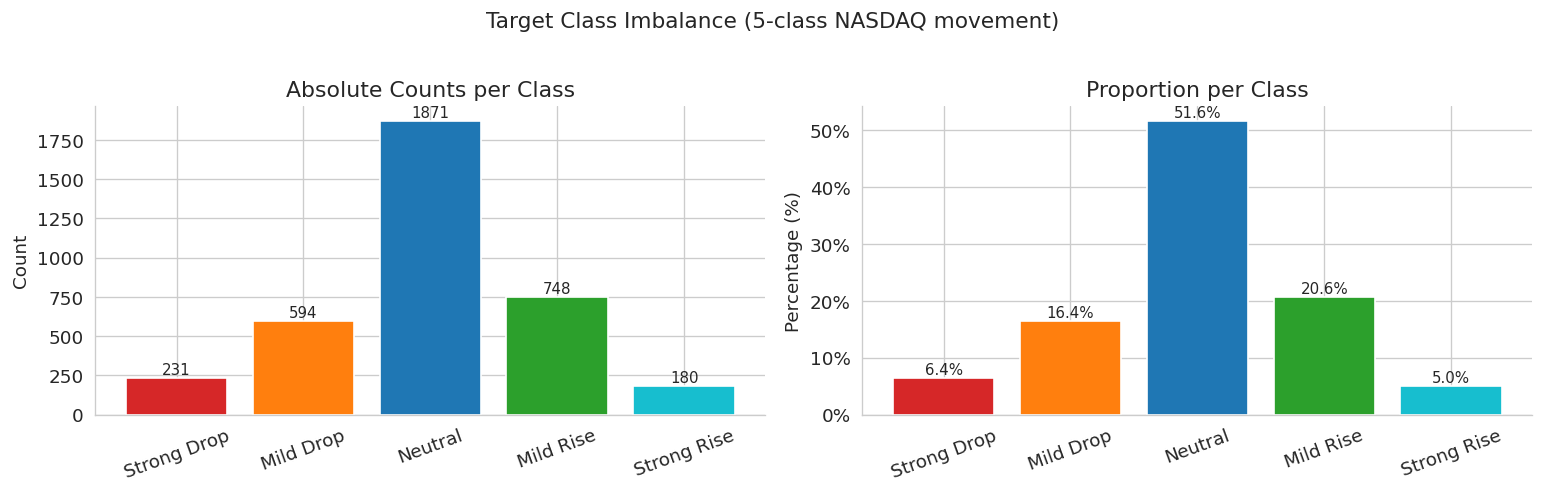

\nClass statistics:
         Class  Count  Proportion (%)  Imbalance Ratio vs Neutral
0  Strong Drop    231            6.37                        8.10
1    Mild Drop    594           16.39                        3.15
2      Neutral   1871           51.63                        1.00
3    Mild Rise    748           20.64                        2.50
4  Strong Rise    180            4.97                       10.39


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: absolute counts
counts = y_clean.value_counts().sort_index()
labels = [CLASS_NAMES[i] for i in counts.index]
colors = ["#d62728","#ff7f0e","#1f77b4","#2ca02c","#17becf"]
axes[0].bar(labels, counts.values, color=colors, edgecolor="white")
for bar, cnt in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(cnt), ha="center", va="bottom", fontsize=9)
axes[0].set_title("Absolute Counts per Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=20)

# Right: proportions
pcts = counts / counts.sum() * 100
axes[1].bar(labels, pcts.values, color=colors, edgecolor="white")
for bar, pct in zip(axes[1].patches, pcts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
axes[1].set_title("Proportion per Class")
axes[1].set_ylabel("Percentage (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Target Class Imbalance (5-class NASDAQ movement)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\\nClass statistics:")
print(pd.DataFrame({
    "Class": [CLASS_NAMES[i] for i in counts.index],
    "Count": counts.values,
    "Proportion (%)": (pcts).round(2).values,
    "Imbalance Ratio vs Neutral": (counts[2] / counts).round(2).values,
}))

## 4. Imbalance Analysis

The table above shows that class 2 (Neutral) dominates with ~52% of all observations,
while classes 0 (Strong Drop, ~6%) and 4 (Strong Rise, ~5%) are minority classes.

The imbalance ratio (Neutral / minority) is approximately **10:1**, which is well within
the range where standard classifiers will default to predicting the majority class.

Without handling, a naive classifier would achieve ~52% accuracy by always predicting
"Neutral" — but zero recall on the economically important extreme classes.

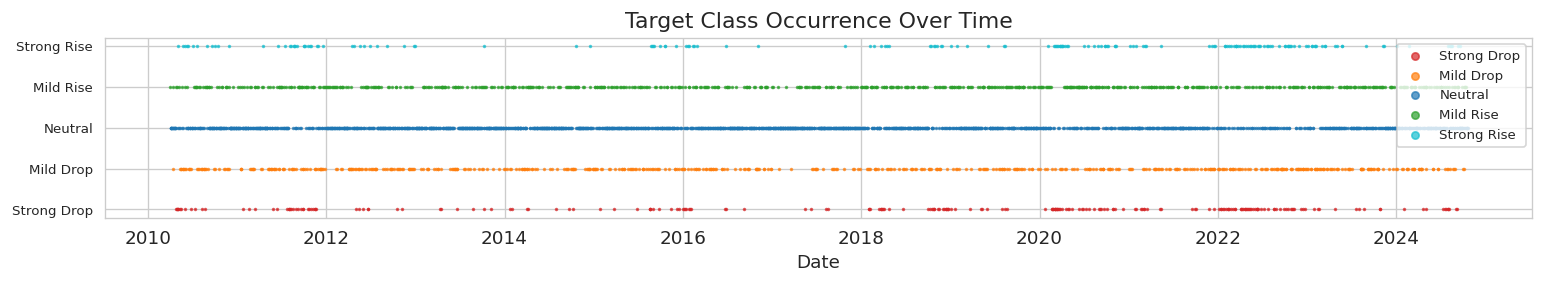

In [5]:
# Timeline of class occurrences
fig, ax = plt.subplots(figsize=(13, 2.5))
color_map = {0: "#d62728", 1: "#ff7f0e", 2: "#1f77b4", 3: "#2ca02c", 4: "#17becf"}
for cls, color in color_map.items():
    mask = df_clean["target_class"] == cls
    ax.scatter(df_clean.loc[mask, "date"], [cls]*mask.sum(),
               c=color, s=1.2, label=CLASS_NAMES[cls], alpha=0.7)
ax.set_yticks([0,1,2,3,4])
ax.set_yticklabels([CLASS_NAMES[i] for i in range(5)], fontsize=8)
ax.set_title("Target Class Occurrence Over Time")
ax.set_xlabel("Date")
ax.legend(loc="upper right", markerscale=4, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_class_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Missing Data Analysis

### 5.1 Original missing values (before MCAR injection)

The dataset has two types of genuine missingness:
- **Market data (~4.7%)**: weekends and public holidays — these rows are dropped entirely.
- **Macro variables (GDP ~98.5%, CPI/Rates ~95.5%)**: discrete publication frequency
  (quarterly / monthly). These are forward-filled following Assignment 1 logic,
  which is defensible as the "last known value" interpretation.

### 5.2 Artificial MCAR injection

For the imputation experiment, we inject **5% MCAR** missingness into 8 technical
indicator features. This allows controlled evaluation of imputation methods
(SimpleImputer, KNNImputer, IterativeImputer) under conditions where we know
the ground truth values.

**Justification:** "To evaluate multivariate imputation methods in a controlled
manner, we introduce 5% MCAR missingness into technical indicator columns.
MCAR ensures that the missingness mechanism introduces no bias, isolating
the quality of imputation reconstruction."

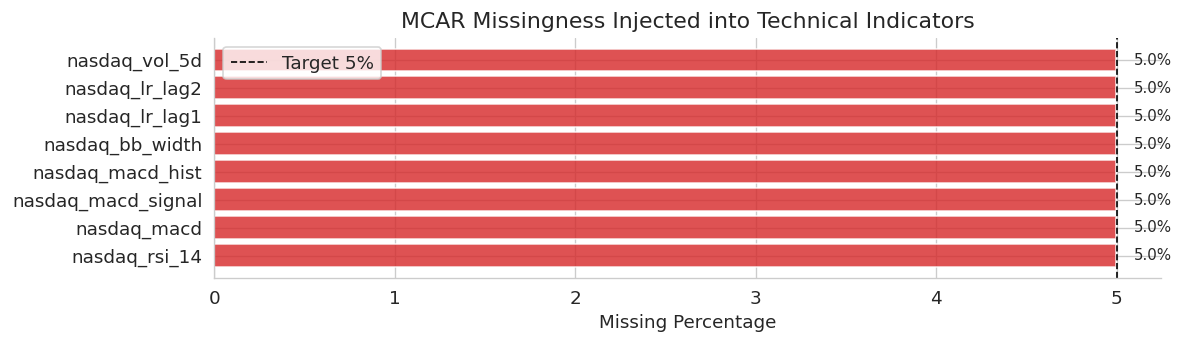

In [6]:
# Show missing pattern in the artificially corrupted dataset
tech_cols = [
    "nasdaq_rsi_14", "nasdaq_macd", "nasdaq_macd_signal",
    "nasdaq_macd_hist", "nasdaq_bb_width",
    "nasdaq_lr_lag1", "nasdaq_lr_lag2", "nasdaq_vol_5d",
]

missing_pct = df_missing[tech_cols].isnull().mean() * 100
fig, ax = plt.subplots(figsize=(10, 3))
ax.barh(missing_pct.index, missing_pct.values, color="#d62728", alpha=0.8)
ax.axvline(5, color="black", linestyle="--", linewidth=1, label="Target 5%")
for i, (col, pct) in enumerate(missing_pct.items()):
    ax.text(pct + 0.1, i, f"{pct:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Missing Percentage")
ax.set_title("MCAR Missingness Injected into Technical Indicators")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_missing_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Feature Correlations with Target

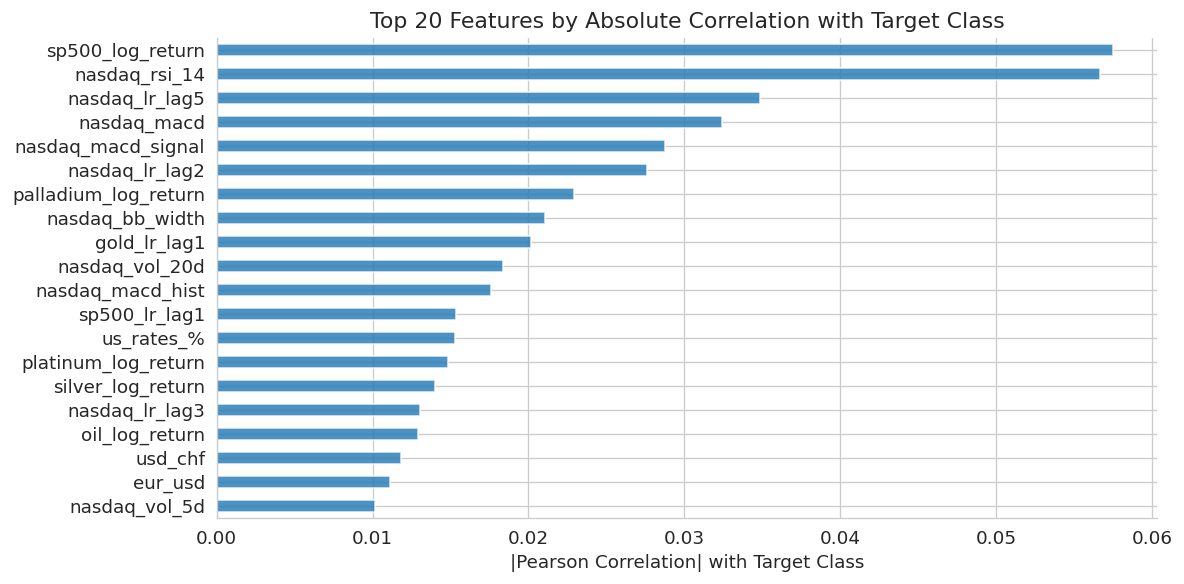

In [7]:
X_num = X_clean.select_dtypes(include="number")
corr_with_target = X_num.corrwith(df_clean["target_class"]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
corr_with_target.head(20).plot(kind="barh", ax=ax, color="#1f77b4", alpha=0.8)
ax.set_xlabel("|Pearson Correlation| with Target Class")
ax.set_title("Top 20 Features by Absolute Correlation with Target Class")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Sumary & Conclusions

### Key findings from EDA

| Finding | Value |
|---------|-------|
| Total samples (after preprocessing) | ~3,700 |
| Class 0 — Strong Drop | ~6.3% |
| Class 1 — Mild Drop | ~16.5% |
| Class 2 — Neutral (majority) | ~51.7% |
| Class 3 — Mild Rise | ~20.7% |
| Class 4 — Strong Rise | ~4.9% |
| Imbalance ratio (Neutral : Strong Drop) | ~10:1 |

### Why this is a challenging problem
- Extreme classes (0 and 4) are rare but **high-stakes** — missing a Strong Drop
  or Strong Rise has large financial consequences.
- A naive classifier predicting always "Neutral" achieves ~52% accuracy but 
  **zero recall** on the most important classes.
- The imbalance is **structural** (determined by the return distribution), not 
  a data collection artefact.

### Plan for next notebooks
- **Notebook 02**: Compare imputation methods on the MCAR-corrupted dataset
- **Notebook 03**: Compare imbalance handling strategies and build the best pipeline


# Save datasets

In [13]:
# Save processed datasets for use in subsequent notebooks
df_clean.to_parquet("../data/df_clean.parquet", index=False, engine='fastparquet')
df_missing.to_parquet("../data/df_missing.parquet", index=False, engine='fastparquet')